# 中证 A500 成分股市盈率（静）/ 市净率统计

- **市盈率（静）**：优先使用 Tushare `daily_basic` 的 **`pe`**（文档口径为总市值/净利润，对应常见「静态 PE」；若列缺失则回退 `pe_ttm` 并会在汇总表里注明）。
- **市净率**：字段 **`pb`**（总市值/净资产）。
- PE、PB 在图里均为**估值倍数**，横纵轴单位记为 **倍**（不是金额「元」）。PE 与 PB 量级不同，箱线图拆成上下两个子图，各自纵轴为「倍」，避免画在同一张图里显得「单位不对」。

数据：`data/<日期>/index/index_weight/000510_CSI.csv`，`data/<日期>/quote/basic/*.csv`。缺数据请先拉取（配置 `TUSHARE_TOKEN`）。


In [1]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    if (here / "data").is_dir():
        return here
    if (here.parent / "data").is_dir():
        return here.parent
    return here


REPO = find_repo_root()
DATA = REPO / "data"
INDEX_FILE = "000510_CSI.csv"

# 可选：固定某日；为 None 时用 data 下最新 YYYYMMDD
DATE_OVERRIDE: str | None = os.environ.get("A500_STATS_DATE")  # 例 "20260410"


def latest_data_date(data_root: Path) -> str | None:
    if not data_root.is_dir():
        return None
    dirs = [p.name for p in data_root.iterdir() if p.is_dir() and p.name.isdigit() and len(p.name) == 8]
    return max(dirs) if dirs else None


date_str = DATE_OVERRIDE or latest_data_date(DATA)
print("仓库根目录:", REPO)
print("使用数据日期:", date_str)

仓库根目录: /Users/yi/Projects/quant-data-foundry
使用数据日期: 20260410


In [2]:
if date_str is None:
    raise SystemExit("未找到 data/<YYYYMMDD>，请先拉取市场数据。")

iw_path = DATA / date_str / "index" / "index_weight" / INDEX_FILE
if not iw_path.is_file():
    raise FileNotFoundError(f"缺少指数权重文件: {iw_path}")

iw = pd.read_csv(iw_path, encoding="utf-8")
if "con_code" not in iw.columns:
    raise ValueError(f"{iw_path} 无 con_code 列")

constituents = iw["con_code"].astype(str).drop_duplicates().sort_values().tolist()
print(f"A500 成分股数量: {len(constituents)}")
iw.head()

A500 成分股数量: 500


,index_code,con_code,trade_date,weight
0,000510.CSI,300750.SZ,20260331,3.780
1,000510.CSI,600519.SH,20260331,3.231
2,000510.CSI,300308.SZ,20260331,2.251
3,000510.CSI,601318.SH,20260331,2.154
4,000510.CSI,601899.SH,20260331,1.918


In [3]:
def ts_to_basic_filename(ts_code: str) -> str:
    return f"{ts_code.replace('.', '_')}.csv"


basic_dir = DATA / date_str / "quote" / "basic"
if not basic_dir.is_dir():
    raise FileNotFoundError(f"缺少每日指标目录: {basic_dir}")

rows: list[pd.Series] = []
missing_files = 0
empty_files = 0

for ts in constituents:
    path = basic_dir / ts_to_basic_filename(ts)
    if not path.is_file():
        missing_files += 1
        continue
    df_b = pd.read_csv(path, encoding="utf-8")
    if df_b.empty:
        empty_files += 1
        continue
    if "trade_date" in df_b.columns:
        df_b = df_b.sort_values("trade_date")
    row = df_b.iloc[-1].copy()
    row["ts_code"] = ts
    rows.append(row)

print(f"有 daily_basic 文件: {len(constituents) - missing_files} / {len(constituents)}")
print(f"空文件: {empty_files}, 缺失文件: {missing_files}")

if not rows:
    raise SystemExit("未读到任何 basic 数据；请确认已执行 fetch 且包含 daily_basic。")

m = pd.DataFrame(rows).reset_index(drop=True)
m.head()

有 daily_basic 文件: 500 / 500
空文件: 0, 缺失文件: 0


,ts_code,trade_date,close,turnover_rate,turnover_rate_f,volume_ratio,pe,pe_ttm,pb,ps,ps_ttm,dv_ratio,dv_ttm,total_share,float_share,free_share,total_mv,circ_mv
0,000001.SZ,20260409,11.10,0.3104,0.7381,0.71,5.0526,5.0526,0.4774,1.6388,1.6388,5.3875,5.3875,1.940592e+06,1.940560e+06,816048.1215,2.154057e+07,2.154022e+07
1,000002.SZ,20260409,3.87,0.8828,1.3250,0.81,NaN,NaN,0.3950,0.1978,0.1978,NaN,NaN,1.193071e+06,9.716936e+05,647412.5074,4.617185e+06,3.760454e+06
2,000009.SZ,20260409,8.67,0.7025,1.1338,0.98,129.5395,317.2862,2.2188,1.1055,0.9981,0.3460,0.3460,2.579214e+05,2.576020e+05,159620.5683,2.236179e+06,2.233410e+06
3,000032.SZ,20260410,17.89,1.8849,3.3792,0.92,65.9321,138.0131,2.9703,0.3226,0.4182,0.6281,0.6281,1.215179e+05,1.137959e+05,63473.8048,2.173956e+06,2.035809e+06
4,000034.SZ,20260409,34.75,4.3455,4.6417,1.61,48.1762,48.1762,2.2890,0.1753,0.1753,0.7472,0.7472,7.249912e+04,6.063202e+04,56762.5719,2.519345e+06,2.106963e+06


In [4]:
# Tushare daily_basic: pe → 市盈率（静）; pe_ttm → 滚动; pb → 市净率（倍）
for col in ("pe", "pe_ttm", "pb"):
    if col in m.columns:
        m[col] = pd.to_numeric(m[col], errors="coerce")

if "pe" in m.columns:
    pe_col = "pe"
    pe_label = "市盈率（静，pe）"
else:
    pe_col = "pe_ttm"
    pe_label = "市盈率（滚动，pe_ttm，无 pe 列时回退）"

if pe_col not in m.columns:
    raise ValueError("DataFrame 中未找到 pe 或 pe_ttm 列")
if "pb" not in m.columns:
    raise ValueError("DataFrame 中未找到 pb 列")

pe_pos = m[pe_col].where(m[pe_col] > 0)
pb_pos = m["pb"].where(m["pb"] > 0)

summary = pd.DataFrame(
    {
        "有效样本数": [pe_pos.notna().sum(), pb_pos.notna().sum()],
        "均值（倍）": [pe_pos.mean(), pb_pos.mean()],
        "中位数（倍）": [pe_pos.median(), pb_pos.median()],
        "25%分位（倍）": [pe_pos.quantile(0.25), pb_pos.quantile(0.25)],
        "75%分位（倍）": [pe_pos.quantile(0.75), pb_pos.quantile(0.75)],
    },
    index=[f"{pe_label}，>0", "市净率（pb，>0）"],
)
summary


,有效样本数,均值（倍）,中位数（倍）,25%分位（倍）,75%分位（倍）
市盈率（静，pe），>0,445,79.244039,30.10840,17.93310,57.27890
市净率（pb，>0）,500,4.293016,2.73515,1.69995,4.67615


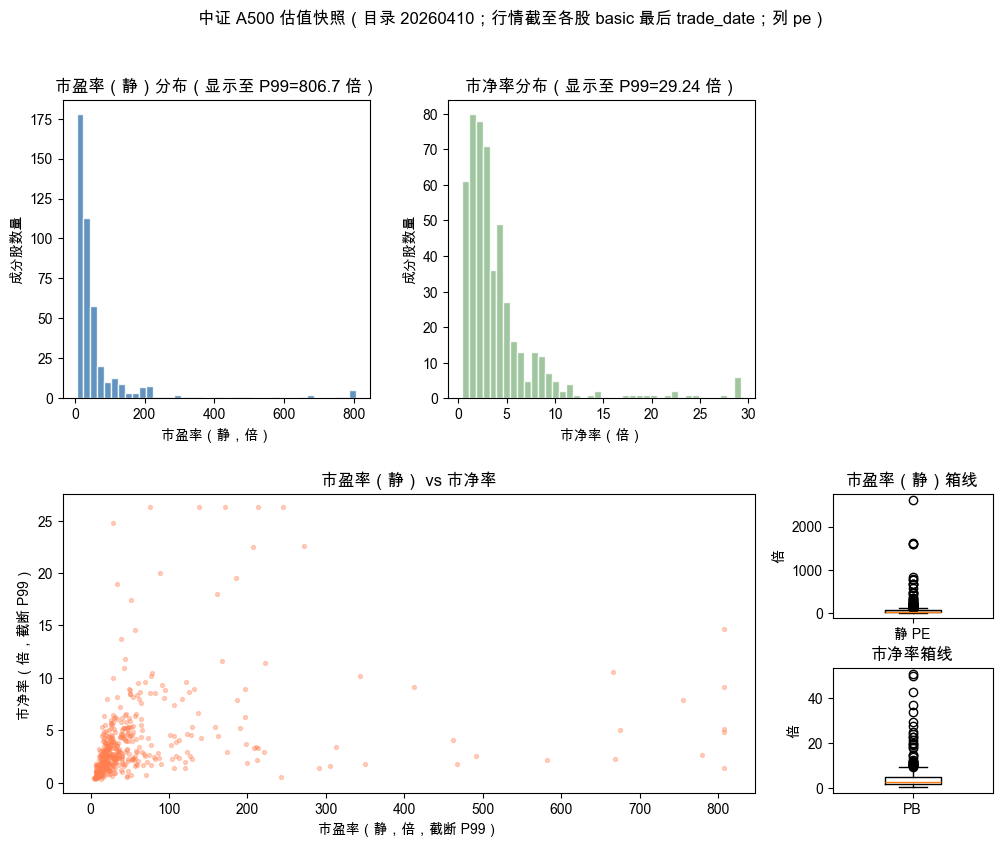

In [5]:
plt.rcParams["font.sans-serif"] = ["PingFang SC", "Arial Unicode MS", "Heiti TC", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

winsor_hi = 99  # 直方图/散点截断百分位，减轻极端值拉长横轴

pe_plot = pe_pos.dropna()
pb_plot = pb_pos.dropna()
pe_hi = np.percentile(pe_plot, winsor_hi) if len(pe_plot) else np.nan
pb_hi = np.percentile(pb_plot, winsor_hi) if len(pb_plot) else np.nan

fig = plt.figure(figsize=(12, 9))
gs = fig.add_gridspec(2, 3, width_ratios=[1.0, 1.0, 0.52], hspace=0.32, wspace=0.3)
ax_peh = fig.add_subplot(gs[0, 0])
ax_pbh = fig.add_subplot(gs[0, 1])
ax_sct = fig.add_subplot(gs[1, 0:2])
gs_box = gs[1, 2].subgridspec(2, 1, hspace=0.4)
ax_bpe = fig.add_subplot(gs_box[0, 0])
ax_bpb = fig.add_subplot(gs_box[1, 0])

ax_peh.hist(pe_plot.clip(upper=pe_hi), bins=40, color="steelblue", edgecolor="white", alpha=0.85)
ax_peh.set_title(f"市盈率（静）分布（显示至 P{winsor_hi}={pe_hi:.1f} 倍）")
ax_peh.set_xlabel("市盈率（静，倍）")
ax_peh.set_ylabel("成分股数量")

ax_pbh.hist(pb_plot.clip(upper=pb_hi), bins=40, color="darkseagreen", edgecolor="white", alpha=0.85)
ax_pbh.set_title(f"市净率分布（显示至 P{winsor_hi}={pb_hi:.2f} 倍）")
ax_pbh.set_xlabel("市净率（倍）")
ax_pbh.set_ylabel("成分股数量")

both = m[["ts_code", pe_col, "pb"]].dropna()
both = both[(both[pe_col] > 0) & (both["pb"] > 0)]
if len(both):
    pe_s = both[pe_col].clip(upper=np.percentile(both[pe_col], winsor_hi))
    pb_s = both["pb"].clip(upper=np.percentile(both["pb"], winsor_hi))
    ax_sct.scatter(pe_s, pb_s, s=8, alpha=0.35, c="coral")
ax_sct.set_xlabel(f"市盈率（静，倍，截断 P{winsor_hi}）")
ax_sct.set_ylabel(f"市净率（倍，截断 P{winsor_hi}）")
ax_sct.set_title("市盈率（静） vs 市净率")

if len(pe_plot):
    ax_bpe.boxplot([pe_plot.to_numpy()], widths=0.35)
    ax_bpe.set_xticks([1])
    ax_bpe.set_xticklabels(["静 PE"])
    ax_bpe.set_ylabel("倍")
    ax_bpe.set_title("市盈率（静）箱线")
if len(pb_plot):
    ax_bpb.boxplot([pb_plot.to_numpy()], widths=0.35)
    ax_bpb.set_xticks([1])
    ax_bpb.set_xticklabels(["PB"])
    ax_bpb.set_ylabel("倍")
    ax_bpb.set_title("市净率箱线")

fig.suptitle(
    f"中证 A500 估值快照（目录 {date_str}；行情截至各股 basic 最后 trade_date；列 {pe_col}）",
    fontsize=12,
)
plt.show()


In [6]:
top_n = 15
valid = m[["ts_code", pe_col, "pb"]].copy()
valid_pe = valid[valid[pe_col] > 0].nsmallest(top_n, pe_col)
valid_pb = valid[valid["pb"] > 0].nsmallest(top_n, "pb")

print(f"市盈率（静）最低 {top_n} 只（{pe_col}>0）:")
display(valid_pe)
print(f"市净率最低 {top_n} 只（pb>0）:")
display(valid_pb)


市盈率（静）最低 15 只（pe>0）:


,ts_code,pe,pb
409,601668.SH,4.4463,0.4259
0,000001.SZ,5.0526,0.4774
384,601166.SH,5.0811,0.4861
387,601186.SH,5.1545,0.3452
398,601390.SH,5.6616,0.4072
396,601328.SH,6.3208,0.5289
30,000651.SZ,6.4987,1.5065
249,600008.SH,6.5124,1.1157
246,600000.SH,6.5857,0.4469
260,600036.SH,6.5929,0.9039


市净率最低 15 只（pb>0）:


,ts_code,pe,pb
387,601186.SH,5.1545,0.3452
263,600048.SH,13.3319,0.3555
1,000002.SZ,NaN,0.3950
398,601390.SH,5.6616,0.4072
409,601668.SH,4.4463,0.4259
417,601800.SH,8.3407,0.4261
246,600000.SH,6.5857,0.4469
276,600153.SH,8.6519,0.4624
0,000001.SZ,5.0526,0.4774
384,601166.SH,5.0811,0.4861
